
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

In [1]:
import numpy as np

np.random.seed(42)

X = np.random.rand(1000, 2)

epsilon = np.random.normal(loc=0, scale=1, size=1000)

y = 3 * X[:, 0] + 5 * X[:, 1] + 3 + epsilon

X = np.c_[np.ones(1000), X]

X.shape, y.shape

X[:5]

array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)

&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.

<details>

<summary>Answer</summary>

a) 

<img src="../data/grad_desc_converg.png" height="200"/>

b) 

<img src="../data/grad_desc_converg_001.png" height="200"/>

</details>

---

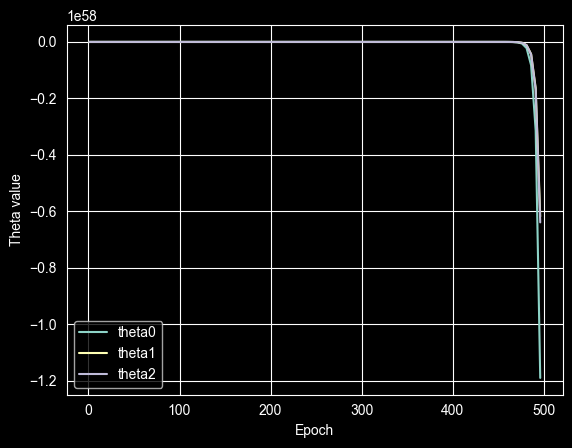

In [2]:
import numpy as np
import matplotlib.pyplot as plt

m, n = X.shape
theta = np.zeros(n)

eta = 0.1
epochs = 500
"""
# eta = 0.1 (ofta instabil)
# eta = 0.01 (brukar funka)
# eta = 0.005
# eta = 0.001 (stabil men långsam)
"""

epochs_list = []
theta_list = []
cost_list = []

for epoch in range(1, epochs + 1):
    y_pred = X @ theta
    error = y - y_pred
    grad = (2/m) * (X.T @ error)
    theta = theta - eta * grad

    cost = (1/m) * np.sum(np.square(error))

    if epoch % 5 ==1:
        epochs_list.append(epoch)
        theta_list.append(theta.copy())
        cost_list.append(cost)

theta_array = np.array(theta_list)

plt.figure()
plt.plot(epochs_list, theta_array[:, 0], label="theta0")
plt.plot(epochs_list, theta_array[:, 1], label="theta1")
plt.plot(epochs_list, theta_array[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta value")
plt.legend()
plt.show()

Final theta (1b): [3.12100926 2.95383681 4.83245004]


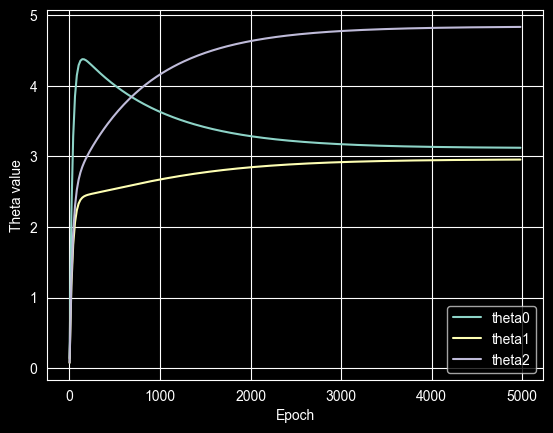

In [3]:
#a)
m, n = X.shape
theta = np.zeros(n)

eta = 0.01
epochs = 5000

epochs_list = []
theta_list = []
cost_list = []

for epoch in range(1, epochs + 1):
    y_pred = X @ theta
    error = y_pred - y
    grad = (2/m) * (X.T @ error)
    theta = theta - eta * grad

    cost = (1/m) * np.sum(error**2)

    if epoch % 20 == 1:
        epochs_list.append(epoch)
        theta_list.append(theta.copy())
        cost_list.append(cost)

theta_b = theta.copy()
theta_array = np.array(theta_list)

print("Final theta (1b):", theta_b)

plt.figure()
plt.plot(epochs_list, theta_array[:, 0], label="theta0")
plt.plot(epochs_list, theta_array[:, 1], label="theta1")
plt.plot(epochs_list, theta_array[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta value")
plt.legend()
plt.show()

## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

In [4]:
m, n = X.shape
theta = np.zeros(n)

eta = 0.01
epochs = 600

epochs_list = []
theta_list = []
cost_list = []

for epoch in range(1, epochs + 1):
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(m):
        xi = X_shuffled[i]
        yi = y_shuffled[i]

        error = xi @ theta - yi
        grad = 2 * error * xi
        theta = theta - eta * grad

    y_pred = X @ theta
    cost = (1/m) * np.sum((y_pred - y)**2)

    epochs_list.append(epoch)
    theta_list.append(theta.copy())
    cost_list.append(cost)

print (theta)

[3.23219537 2.95929018 4.90697932]


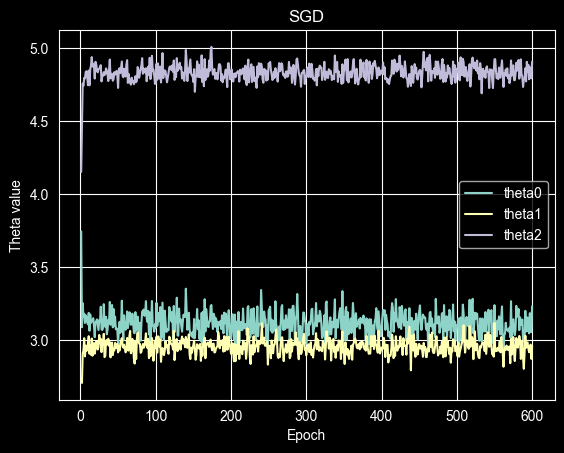

In [5]:
theta_array = np.array(theta_list)

plt.figure()
plt.plot(epochs_list, theta_array[:,0], label="theta0")
plt.plot(epochs_list, theta_array[:,1], label="theta1")
plt.plot(epochs_list, theta_array[:,2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta value")
plt.title("SGD")
plt.legend()
plt.show()

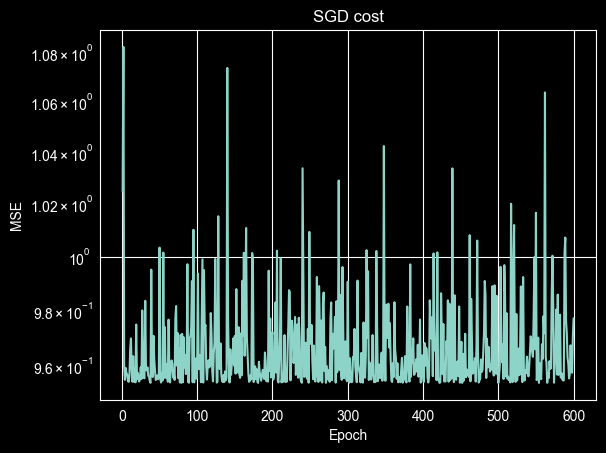

In [6]:
plt.figure()
plt.plot(epochs_list, cost_list)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.yscale("log")
plt.title("SGD cost")
plt.show()

## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

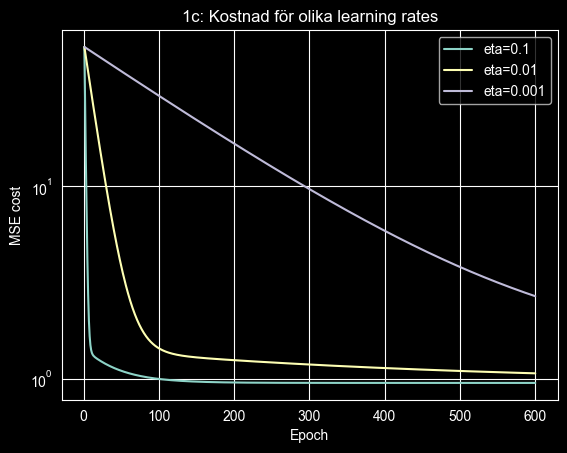

In [7]:
etas = [0.1, 0.01, 0.001]
epochs = 600

plt.figure()
for eta in etas:
    theta = np.zeros(X.shape[1])
    costs = []

    for epoch in range(1, epochs + 1):
        y_pred = X @ theta
        error = y_pred - y
        grad = (2/m) * (X.T @ error)
        theta = theta - eta * grad
        cost = (1/m) * np.sum(error**2)
        costs.append(cost)

    plt.plot(range(1, epochs + 1), costs, label=f"eta={eta}")

plt.xlabel("Epoch")
plt.ylabel("MSE cost")
plt.title("1c: Kostnad för olika learning rates")
plt.yscale("log")  # konvergens
plt.legend()
plt.show()

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---